# Data Cleaning and Feature Engineering

Importing some of the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
from datetime import datetime

def styled(obj, caption="", dots=False):
    # If the object is a Series, convert it to a DataFrame
    if isinstance(obj, pd.Series):
        obj = obj.to_frame().T  # Convert Series to one-row DataFrame

    # If the number of rows or columns is small, display the table as is
    if isinstance(obj, pd.DataFrame) and obj.shape[0] <= 3 and obj.shape[1] <= 3:
        return (
            obj.style
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': '.row_heading', 'props': [('text-align', 'left')]}
            ])
            .set_caption(caption)
        )

    # Handle dots view for large DataFrames
    if dots and isinstance(obj, pd.DataFrame) and len(obj) > 6:
        head = obj.head(3)
        tail = obj.tail(3)

        # Create a DataFrame with the same columns and '...' as a row
        ellipsis_row = pd.DataFrame([['...'] * obj.shape[1]], columns=obj.columns)
        ellipsis_row.index = ['...']  # Set a placeholder index

        # Concatenate with original indexes preserved
        obj = pd.concat([head, ellipsis_row, tail])

    return (
        obj.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': '.row_heading', 'props': [('text-align', 'left')]}
        ])
        .set_caption(caption)
    )

print(os.listdir("/kaggle/input"))

['delivery']


reading data

In [2]:
data = pd.read_csv("/kaggle/input/delivery/data.csv")

In [3]:
styled(data.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [5]:
styled(data.describe())

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [6]:
styled(data.describe(include='O'))

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
count,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593
unique,45593,1320,23,29,44,177,193,7,5,4,4,5,3,4,45
top,0x4607,PUNERES01DEL01,35,4.8,15-03-2022,NaN,21:30:00,conditions Fog,Low,Snack,motorcycle,1,No,Metropolitian,(min) 26
freq,1,67,2262,7148,1192,1731,496,7654,15477,11533,26435,28159,44469,34093,2123


Convert numeric columns

In [7]:
data["Delivery_person_Age"] = pd.to_numeric(data["Delivery_person_Age"], errors="coerce").astype("Int64")
data["Delivery_person_Ratings"] = pd.to_numeric(data["Delivery_person_Ratings"], errors="coerce")
data["multiple_deliveries"] = pd.to_numeric(data["multiple_deliveries"], errors="coerce").astype("Int64")

Clean and convert Time_taken(min)

In [8]:
data["Time_taken(min)"] = (data["Time_taken(min)"].str.replace("(min)", "", regex=False).str.strip())
data["Time_taken(min)"] = pd.to_numeric(data["Time_taken(min)"], errors="coerce").astype("Int64")

Convert date column

In [9]:
data["Order_Date"] = pd.to_datetime(data["Order_Date"], format="%d-%m-%Y", errors="coerce")

Convert time columns

In [10]:
data["Time_Orderd"] = pd.to_datetime(data["Time_Orderd"], format="%H:%M:%S", errors="coerce").dt.time
data["Time_Order_picked"] = pd.to_datetime(data["Time_Order_picked"], format="%H:%M:%S", errors="coerce").dt.time

In [11]:
styled(data.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.900000,22.745049,75.892471,22.765049,75.912471,2022-03-19 00:00:00,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,24
1,0xb379,BANGRES18DEL02,34,4.500000,12.913041,77.683237,13.043041,77.813237,2022-03-25 00:00:00,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23,4.400000,12.914264,77.678400,12.924264,77.688400,2022-03-19 00:00:00,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38,4.700000,11.003669,76.976494,11.053669,77.026494,2022-04-05 00:00:00,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32,4.600000,12.972793,80.249982,13.012793,80.289982,2022-03-26 00:00:00,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30


Clean Weatherconditions (remove "conditions " prefix)

In [12]:
data["Weatherconditions"] = data["Weatherconditions"].str.replace("conditions ", "", regex=False).str.strip()

Standardize City names

In [13]:
data["City"] = data["City"].str.strip().replace({
    "Metropolitian": "Metropolitan",
    "Urban ": "Urban",
    "Semi-Urban ": "Semi-Urban"
})

Standardize Road_traffic_density

In [14]:
data["Road_traffic_density"] = data["Road_traffic_density"].str.strip().replace({
    "jam": "Jam",
    "low": "Low",
    "medium": "Medium",
    "high": "High"
})

Checking nulls after fixing data types

In [15]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0,0,1854,1908,0,0,0,0,0,1731,0,0,0,0,0,0,993,0,0,0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45593 non-null  object        
 1   Delivery_person_ID           45593 non-null  object        
 2   Delivery_person_Age          43739 non-null  Int64         
 3   Delivery_person_Ratings      43685 non-null  float64       
 4   Restaurant_latitude          45593 non-null  float64       
 5   Restaurant_longitude         45593 non-null  float64       
 6   Delivery_location_latitude   45593 non-null  float64       
 7   Delivery_location_longitude  45593 non-null  float64       
 8   Order_Date                   45593 non-null  datetime64[ns]
 9   Time_Orderd                  43862 non-null  object        
 10  Time_Order_picked            45593 non-null  object        
 11  Weatherconditions            45593 non-nu

Some non-numerical columns have "NaN" stored as strings instead of true missing values

In [17]:
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].replace("NaN", np.nan)
    print(f"{col}: {data[col].unique()}")

ID: ['0x4607 ' '0xb379 ' '0x5d6d ' ... '0x4f8d ' '0x5eee ' '0x5fb2 ']
Delivery_person_ID: ['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' ...
 'KOCRES04DEL01 ' 'BHPRES06DEL03 ' 'GOARES03DEL03 ']
Time_Orderd: [datetime.time(11, 30) datetime.time(19, 45) datetime.time(8, 30)
 datetime.time(18, 0) datetime.time(13, 30) datetime.time(21, 20)
 datetime.time(19, 15) datetime.time(17, 25) datetime.time(20, 55)
 datetime.time(21, 55) datetime.time(14, 55) datetime.time(17, 30)
 datetime.time(9, 20) datetime.time(19, 50) datetime.time(20, 25)
 datetime.time(20, 30) datetime.time(20, 40) datetime.time(21, 15)
 datetime.time(20, 20) datetime.time(22, 30) datetime.time(8, 15)
 datetime.time(19, 30) datetime.time(12, 25) datetime.time(18, 35)
 datetime.time(20, 35) datetime.time(23, 20) datetime.time(23, 35)
 datetime.time(22, 35) datetime.time(23, 25) datetime.time(13, 35)
 datetime.time(21, 35) datetime.time(18, 55) datetime.time(14, 15)
 datetime.time(11, 0) datetime.time(9, 45) datetime.

Replace "NaN" strings with actual np.nan

In [18]:
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].replace("NaN", np.nan)
data['Festival'] = data['Festival'].replace('NaN ', np.nan)

In [19]:
data['Festival'].unique()

array(['No ', 'Yes ', nan], dtype=object)

Checking nulls

In [20]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0,0,1854,1908,0,0,0,0,0,1731,0,616,601,0,0,0,993,228,1200,0


In [21]:
rows_with_nulls = data.isnull().any(axis=1).sum()
total_rows = len(data)
percentage_null_rows = (rows_with_nulls / total_rows) * 100
print(f"Rows with at least one null: {rows_with_nulls}")
print(f"Percentage: {percentage_null_rows:.2f}%")

Rows with at least one null: 4225
Percentage: 9.27%


Checking unlogical data

In [22]:
print("Age: ", data["Delivery_person_Age"].min(), "–", data["Delivery_person_Age"].max())
print("Ratings: ", data["Delivery_person_Ratings"].min(), "–", data["Delivery_person_Ratings"].max())
print("Vehicle_condition unique values: ", data["Vehicle_condition"].unique())
print("Time taken: ", data["Time_taken(min)"].min(), "–", data["Time_taken(min)"].max())


Age:  15 – 50
Ratings:  1.0 – 6.0
Vehicle_condition unique values:  [2 0 1 3]
Time taken:  10 – 54


Checking first and last day date of data

In [23]:
print("First day in data:", data["Order_Date"].min())
print("Last day in data :", data["Order_Date"].max())

First day in data: 2022-02-11 00:00:00
Last day in data : 2022-04-06 00:00:00


- Fill missing ages using known values for the same Delivery_person_ID
- Note: age is unlikely to change, because the data is for 2 months only in 2022

In [24]:
data["Delivery_person_Age"] = data.groupby("Delivery_person_ID")["Delivery_person_Age"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

In [25]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0,0,0,1908,0,0,0,0,0,1731,0,616,601,0,0,0,993,228,1200,0


Fill missing ratings using the average rating of the same Delivery_person_ID

In [26]:
data["Delivery_person_Ratings"] = data.groupby("Delivery_person_ID")["Delivery_person_Ratings"].transform(lambda x: x.fillna(x.mean()))

filling the missing Festival values by looking at other orders on the same Order_Date and using the most common value (Yes or No) for that date.

In [27]:
data['Festival'] = data.groupby('Order_Date')['Festival'] \
                       .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'No'))


In [28]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0,0,0,0,0,0,0,0,0,1731,0,616,601,0,0,0,993,0,1200,0


Filling missing Time_Orderd by estimating it as Time_Order_picked minus the average pick-up delay.

In [29]:
# Ensure date is datetime
data["Order_Date"] = pd.to_datetime(data["Order_Date"])

# Combine date + time into full datetime for calculation
data["Time_Orderd_dt"] = pd.to_datetime(
    data["Order_Date"].astype(str) + " " + data["Time_Orderd"].astype(str),
    errors="coerce"
)
data["Time_Order_picked_dt"] = pd.to_datetime(
    data["Order_Date"].astype(str) + " " + data["Time_Order_picked"].astype(str),
    errors="coerce"
)

# Calculate time differences where both are available
valid_diff = (data["Time_Order_picked_dt"] - data["Time_Orderd_dt"]).dropna()

# Average difference
avg_diff = valid_diff.mean()

# Mode (most common difference)
mode_diff = valid_diff.mode()[0]

# Convert both to readable units
avg_minutes = avg_diff.total_seconds() / 60
mode_minutes = mode_diff.total_seconds() / 60

print(f"Average difference: {avg_minutes:.2f} minutes")
print(f"Most common difference (mode): {mode_minutes:.2f} minutes")

# Fill missing Time_Orderd using mode difference
mask_missing = data["Time_Orderd_dt"].isna() & data["Time_Order_picked_dt"].notna()
data.loc[mask_missing, "Time_Orderd_dt"] = data.loc[mask_missing, "Time_Order_picked_dt"] - mode_diff

# Keep only the time part if needed
data["Time_Orderd"] = data["Time_Orderd_dt"].dt.time

Average difference: -17.29 minutes
Most common difference (mode): 5.00 minutes


In [30]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt
0,0,0,0,0,0,0,0,0,0,0,0,616,601,0,0,0,993,0,1200,0,0,0


In [31]:
styled(data.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt
0,0x4607,INDORES13DEL02,37,4.900000,22.745049,75.892471,22.765049,75.912471,2022-03-19 00:00:00,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,2022-03-19 11:30:00,2022-03-19 11:45:00
1,0xb379,BANGRES18DEL02,34,4.500000,12.913041,77.683237,13.043041,77.813237,2022-03-25 00:00:00,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitan,33,2022-03-25 19:45:00,2022-03-25 19:50:00
2,0x5d6d,BANGRES19DEL01,23,4.400000,12.914264,77.678400,12.924264,77.688400,2022-03-19 00:00:00,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,2022-03-19 08:30:00,2022-03-19 08:45:00
3,0x7a6a,COIMBRES13DEL02,38,4.700000,11.003669,76.976494,11.053669,77.026494,2022-04-05 00:00:00,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitan,21,2022-04-05 18:00:00,2022-04-05 18:10:00
4,0x70a2,CHENRES12DEL01,32,4.600000,12.972793,80.249982,13.012793,80.289982,2022-03-26 00:00:00,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitan,30,2022-03-26 13:30:00,2022-03-26 13:45:00


Checking the ration of each weather condition

In [32]:
counts = data["Weatherconditions"].value_counts()

# Percentage of each weather condition
percentages = data["Weatherconditions"].value_counts(normalize=True) * 100

# Combine in one table
weather_stats = pd.DataFrame({
    "Count": counts,
    "Percentage": percentages.round(2)
})

styled(weather_stats)

,Count,Percentage
Weatherconditions,,
Fog,7654,17.020000
Stormy,7586,16.870000
Cloudy,7536,16.760000
Sandstorms,7495,16.660000
Windy,7422,16.500000
Sunny,7284,16.190000


Since the distribution of weather conditions is expected to be relatively balanced, I will handle missing values by imputing them with the most frequent weather condition observed for the same month and hour of the day. This ensures that the imputation respects temporal patterns in the data, rather than relying on a single global mode.

In [33]:
# Extract Month and Hour
data["Month"] = data["Time_Orderd_dt"].dt.month
data["Hour"] = data["Time_Orderd_dt"].dt.hour

# Fill missing Weatherconditions by mode per (Month, Hour)
data["Weatherconditions"] = data.groupby(["Month", "Hour"])["Weatherconditions"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)


Filling missing traffic density values using the most frequent condition (mode) at the same hour of the day

In [34]:
data["Road_traffic_density"] = data.groupby("Hour")["Road_traffic_density"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)


In [35]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt,Month,Hour
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,993,0,1200,0,0,0,0,0


The 'multiple_deliveries' column is filled with the most frequent number of deliveries that this Delivery person do in this hour

In [36]:
# Extract hour from the order datetime
data["Hour"] = pd.to_datetime(data["Time_Orderd_dt"], errors="coerce").dt.hour

# Function to fill missing deliveries
def fill_deliveries(row):
    if pd.isna(row["multiple_deliveries"]):
        mode_value = (
            data[(data["Delivery_person_ID"] == row["Delivery_person_ID"]) &
                 (data["Hour"] == row["Hour"])]
            ["multiple_deliveries"]
            .mode()
        )
        if not mode_value.empty:
            return mode_value[0]
    return row["multiple_deliveries"]

# Apply the function
data["multiple_deliveries"] = data.apply(fill_deliveries, axis=1)


In [37]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt,Month,Hour
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,80,0,1200,0,0,0,0,0


There are some multiple_deliveries count that we did not determine, so we will fill them by the mode

In [38]:
global_mode = data['multiple_deliveries'].mode().iloc[0]
data['multiple_deliveries'].fillna(global_mode, inplace=True)

filling the missing values in the City column by the most frequent city (mode) associated with each delivery person

In [39]:
data['City'] = data.groupby('Delivery_person_ID')['City']\
               .transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)


In [40]:
styled(data.isnull().sum())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt,Month,Hour
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Feature Engineering**

Note: Certain feature engineering steps were already incorporated during the data cleaning stage, such as extracting the month and hour from the order timestamps.

Extract day of week

In [41]:
data['Day_of_week'] = data['Order_Date'].dt.day_name()

Compute preparation time

In [42]:
data['prep_time_min'] = (data['Time_Order_picked_dt'] - data['Time_Orderd_dt']).dt.total_seconds() / 60

Compute distance between restaurant and delivery location

In [43]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c  # distance in km

data['delivery_distance_km'] = haversine(
    data['Restaurant_latitude'], data['Restaurant_longitude'],
    data['Delivery_location_latitude'], data['Delivery_location_longitude']
)


In [44]:
print(f"number of data points with unlogical distance {(data['delivery_distance_km'] > 30).sum()}")

number of data points with unlogical distance 431


We will drop them

In [45]:
data = data[data['delivery_distance_km'] <= 30]

In [46]:
styled(data.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt,Month,Hour,Day_of_week,prep_time_min,delivery_distance_km
0,0x4607,INDORES13DEL02,37,4.900000,22.745049,75.892471,22.765049,75.912471,2022-03-19 00:00:00,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,2022-03-19 11:30:00,2022-03-19 11:45:00,3,11,Saturday,15.000000,3.025149
1,0xb379,BANGRES18DEL02,34,4.500000,12.913041,77.683237,13.043041,77.813237,2022-03-25 00:00:00,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitan,33,2022-03-25 19:45:00,2022-03-25 19:50:00,3,19,Friday,5.000000,20.183530
2,0x5d6d,BANGRES19DEL01,23,4.400000,12.914264,77.678400,12.924264,77.688400,2022-03-19 00:00:00,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,2022-03-19 08:30:00,2022-03-19 08:45:00,3,8,Saturday,15.000000,1.552758
3,0x7a6a,COIMBRES13DEL02,38,4.700000,11.003669,76.976494,11.053669,77.026494,2022-04-05 00:00:00,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitan,21,2022-04-05 18:00:00,2022-04-05 18:10:00,4,18,Tuesday,10.000000,7.790401
4,0x70a2,CHENRES12DEL01,32,4.600000,12.972793,80.249982,13.012793,80.289982,2022-03-26 00:00:00,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitan,30,2022-03-26 13:30:00,2022-03-26 13:45:00,3,13,Saturday,15.000000,6.210138


In [47]:
styled(data.describe())

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Vehicle_condition,multiple_deliveries,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt,Month,Hour,prep_time_min,delivery_distance_km
count,45162.000000,45162.000000,45162.000000,45162.000000,45162.000000,45162.000000,45162,45162.000000,45162.000000,45162.000000,45162,45162,45162.000000,45162.000000,45162.000000,45162.000000
mean,29.502989,4.633996,17.373889,70.715111,17.437500,70.778722,2022-03-13 18:50:16.022319616,1.017448,0.743966,26.298038,2022-03-14 12:44:09.893715968,2022-03-14 12:27:33.680084736,2.984102,17.414862,-16.603561,9.735396
min,15.000000,1.000000,0.000000,0.000000,0.010000,0.010000,2022-02-11 00:00:00,0.000000,0.000000,10.000000,2022-02-10 23:55:00,2022-02-11 00:00:00,2.000000,0.000000,-1435.000000,1.465067
25%,24.000000,4.500000,12.934179,73.170283,12.985662,73.277753,2022-03-04 00:00:00,0.000000,0.000000,19.000000,2022-03-04 23:50:00,2022-03-04 23:50:00,3.000000,15.000000,5.000000,4.663412
50%,29.000000,4.700000,18.554382,75.898497,18.631440,75.999490,2022-03-15 00:00:00,1.000000,1.000000,26.000000,2022-03-15 17:45:00,2022-03-15 17:50:00,3.000000,19.000000,10.000000,9.220209
75%,35.000000,4.800000,22.732225,78.045359,22.783659,78.101455,2022-03-27 00:00:00,2.000000,1.000000,32.000000,2022-03-27 18:30:00,2022-03-27 18:35:00,3.000000,21.000000,15.000000,13.681490
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,3.000000,3.000000,54.000000,2022-04-06 23:55:00,2022-04-06 23:55:00,4.000000,23.000000,15.000000,20.969489
std,5.797545,0.323034,7.340394,21.203905,7.341762,21.204109,nan,0.833499,0.570886,9.383733,nan,nan,0.543915,4.830061,193.080916,5.608508


In [48]:
styled(data.describe(include='O'))

,ID,Delivery_person_ID,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City,Day_of_week
count,45162,45162,45162,45162,45162,45162,45162,45162,45162,45162,45162
unique,45162,1320,193,193,6,4,4,4,2,3,7
top,0x4607,JAPRES11DEL02,21:55:00,21:30:00,Stormy,Low,Snack,motorcycle,No,Metropolitan,Wednesday
freq,1,67,473,492,7697,15535,11428,26236,44276,34966,7040


Dropping unneeded columns

In [49]:
data.drop('ID',axis=1,inplace=True)

In [50]:
data.to_csv("cleaned_data.csv", index=False)

# Visualization
Exploratory Data Analysis (EDA)

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

1. Data Overview
   # Checking basic info about the dataset

In [52]:
print("Data Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)

Data Shape: (45162, 26)

Data Types:
Delivery_person_ID                     object
Delivery_person_Age                     Int64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[ns]
Time_Orderd                            object
Time_Order_picked                      object
Weatherconditions                      object
Road_traffic_density                   object
Vehicle_condition                       int64
Type_of_order                          object
Type_of_vehicle                        object
multiple_deliveries                     int64
Festival                               object
City                                   object
Time_taken(min)                         Int64
Time_Orderd_dt                 datetime64[ns]
Time_Order_picked_dt           datetime64[n

In [53]:
missing = data.isnull().sum()
print("\nMissing Values:\n", missing[missing > 0])


Missing Values:
 Series([], dtype: int64)


# 2. Target Variable Distribution

# Business Question: What is the distribution of delivery times? 
# (Are most deliveries fast, or do we have long tails with high delays?)

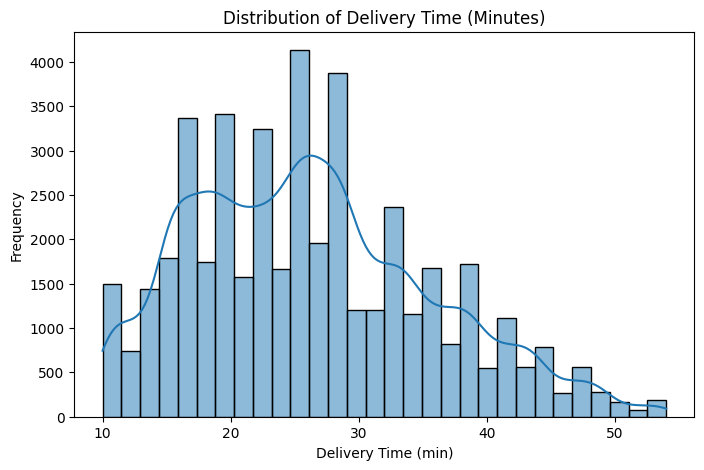

In [54]:
plt.figure(figsize=(8,5))
sns.histplot(data['Time_taken(min)'], kde=True, bins=30)
plt.title("Distribution of Delivery Time (Minutes)")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.show()

# 3. Delivery Time by City

# Business Question: Do certain cities take longer delivery times compared to others?

<Axes: title={'center': 'Distribution of Delivery Time by City'}, xlabel='Delivery Time (min)', ylabel='Frequency'>

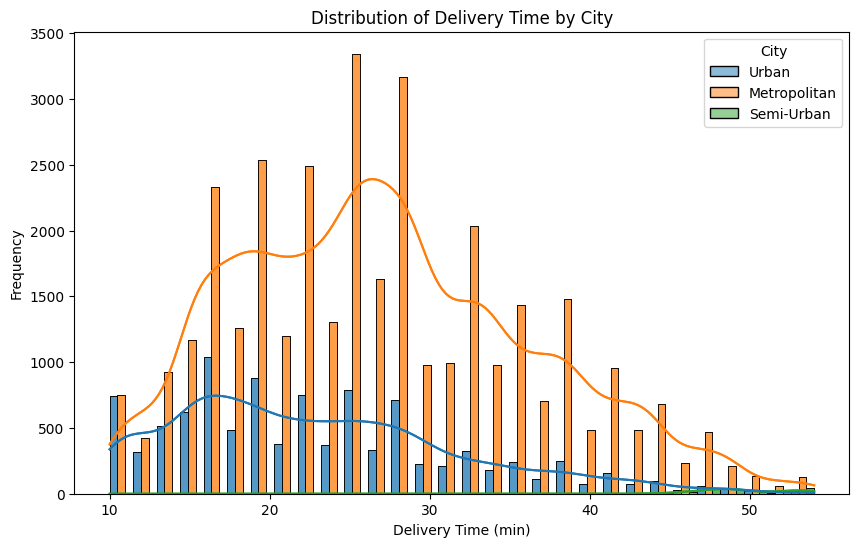

In [55]:
plt.figure(figsize=(10,6))
sns.histplot(data=data, x="Time_taken(min)", hue="City", kde=True, bins=30, multiple="dodge")
plt.title("Distribution of Delivery Time by City")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.legend(title="City")
sns.histplot(data=data, x="Time_taken(min)", hue="City", kde=True, bins=30, multiple="dodge")


# 4. Delivery Time vs Road Traffic
# ==============================
# Business Question: How much impact does traffic density have on delivery time?

  Road_traffic_density       Mean  Median       Std  Count
0                 High  27.239497    27.0  8.406962   4451
1                  Jam  31.184799    31.0     9.941  14183
2                  Low  21.275443    20.0  6.805206  15535
3               Medium  26.709815    27.0  8.556731  10993


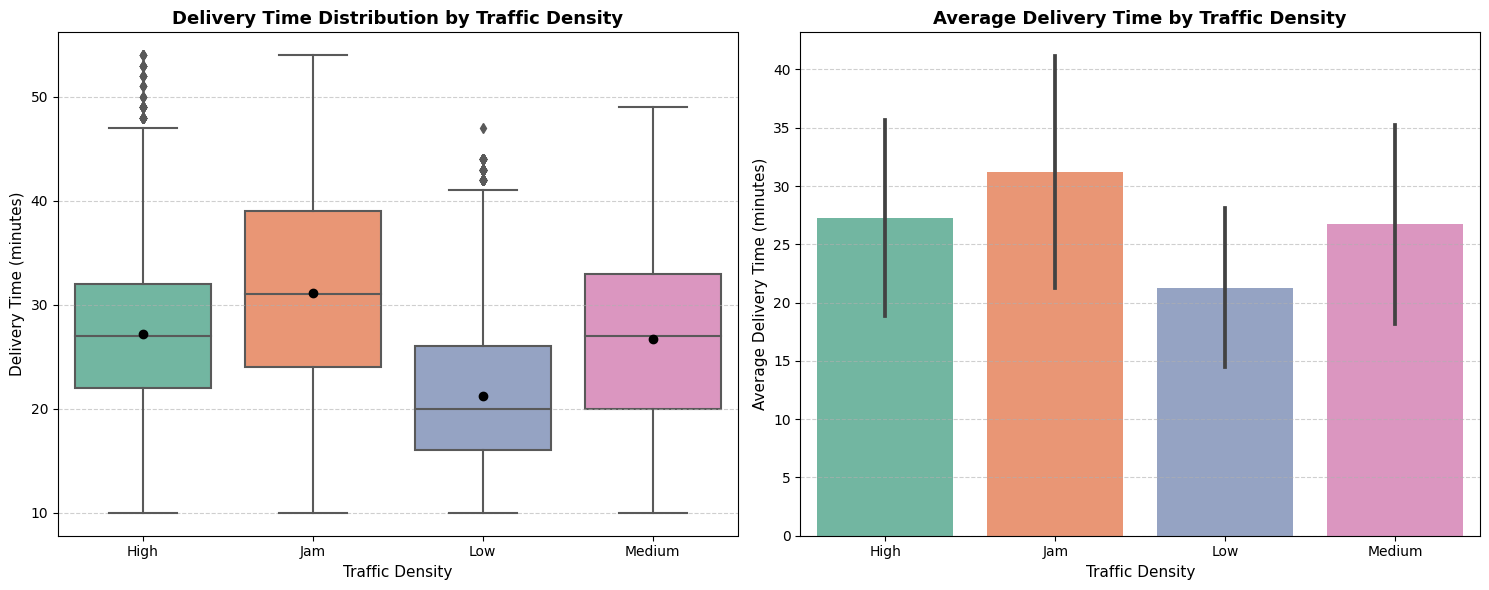

In [56]:

stats = data.groupby("Road_traffic_density")["Time_taken(min)"].agg(
    Mean="mean",
    Median="median",
    Std="std",
    Count="count"
).reset_index()

print(stats)

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# --- Boxplot
sns.boxplot(
    x="Road_traffic_density", 
    y="Time_taken(min)", 
    data=data, 
    palette="Set2", 
    showmeans=True,
    meanprops={"marker":"o",
               "markerfacecolor":"black", 
               "markeredgecolor":"black",
               "markersize":"6"},
    ax=axes[0]
)
axes[0].set_title("Delivery Time Distribution by Traffic Density", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Traffic Density", fontsize=11)
axes[0].set_ylabel("Delivery Time (minutes)", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# --- Barplot 
sns.barplot(
    x="Road_traffic_density", 
    y="Time_taken(min)", 
    data=data, 
    palette="Set2",
    errorbar="sd", 
    ax=axes[1]
)
axes[1].set_title("Average Delivery Time by Traffic Density", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Traffic Density", fontsize=11)
axes[1].set_ylabel("Average Delivery Time (minutes)", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# 5. Delivery Time vs Weather
# Business Question: Do weather conditions affect delivery time?

stats_weather
  Weatherconditions       Mean  Median        Std  Count
0            Cloudy  28.872619    28.0   10.08535   7560
1               Fog  28.929973    29.0  10.124224   7697
2        Sandstorms  25.876004    26.0   8.621524   7468
3            Stormy  25.856697    26.0   8.470682   7697
4             Sunny  21.874467    20.0   8.326384   7265
5             Windy  26.159465    26.0   8.652355   7475


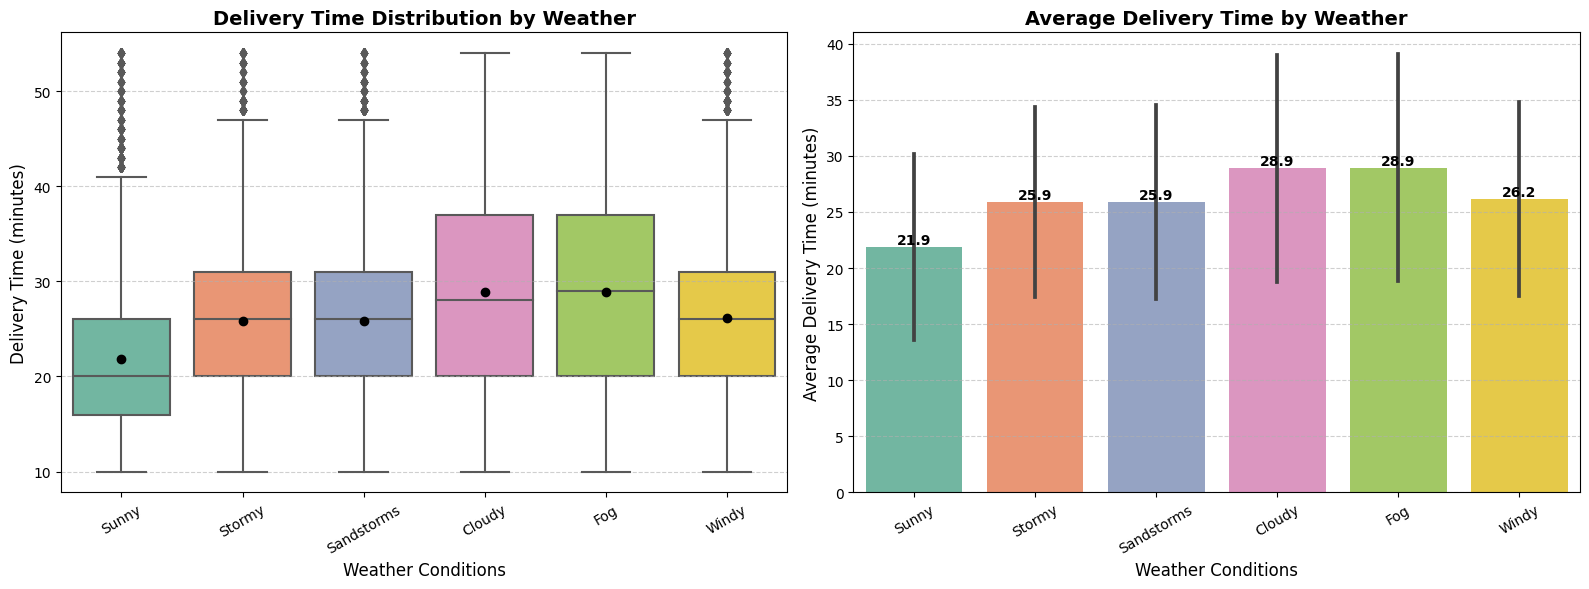

In [57]:

stats_weather = data.groupby("Weatherconditions")["Time_taken(min)"].agg(
    Mean="mean",
    Median="median",
    Std="std",
    Count="count"
).reset_index()

print("stats_weather")
print(stats_weather)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Boxplot 
sns.boxplot(
    x="Weatherconditions", 
    y="Time_taken(min)", 
    data=data, 
    palette="Set2", 
    showmeans=True,
    meanprops={"marker":"o",
               "markerfacecolor":"black", 
               "markeredgecolor":"black",
               "markersize":"6"},
    ax=axes[0]
)
axes[0].set_title("Delivery Time Distribution by Weather", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Weather Conditions", fontsize=12)
axes[0].set_ylabel("Delivery Time (minutes)", fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# --- Barplot 
sns.barplot(
    x="Weatherconditions", 
    y="Time_taken(min)", 
    data=data, 
    palette="Set2",
    errorbar="sd", 
    ax=axes[1]
)

for p in axes[1].patches:
    value = p.get_height()
    axes[1].annotate(f"{value:.1f}", 
                     (p.get_x() + p.get_width() / 2., value), 
                     ha='center', va='bottom', fontsize=10, fontweight="bold")

axes[1].set_title("Average Delivery Time by Weather", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Weather Conditions", fontsize=12)
axes[1].set_ylabel("Average Delivery Time (minutes)", fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# 6. Distance vs Delivery Time
# Business Question: Does a longer distance lead to longer delivery time?

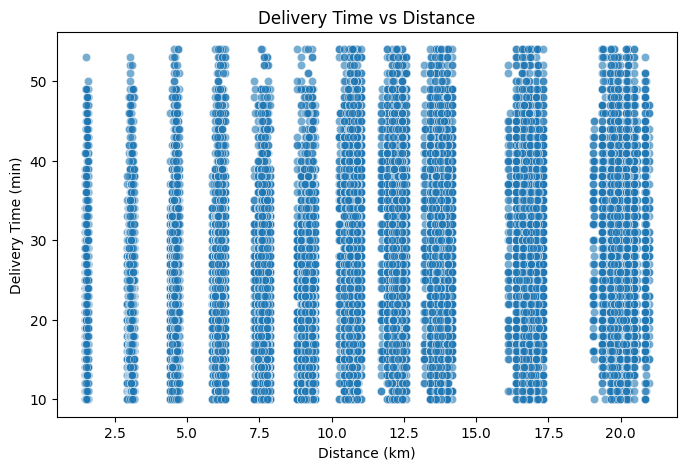

In [58]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="delivery_distance_km", y="Time_taken(min)", data=data, alpha=0.6)
plt.title("Delivery Time vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

# 7. Delivery Time by Type of Order
# Business Question: Do certain food types take longer to deliver?

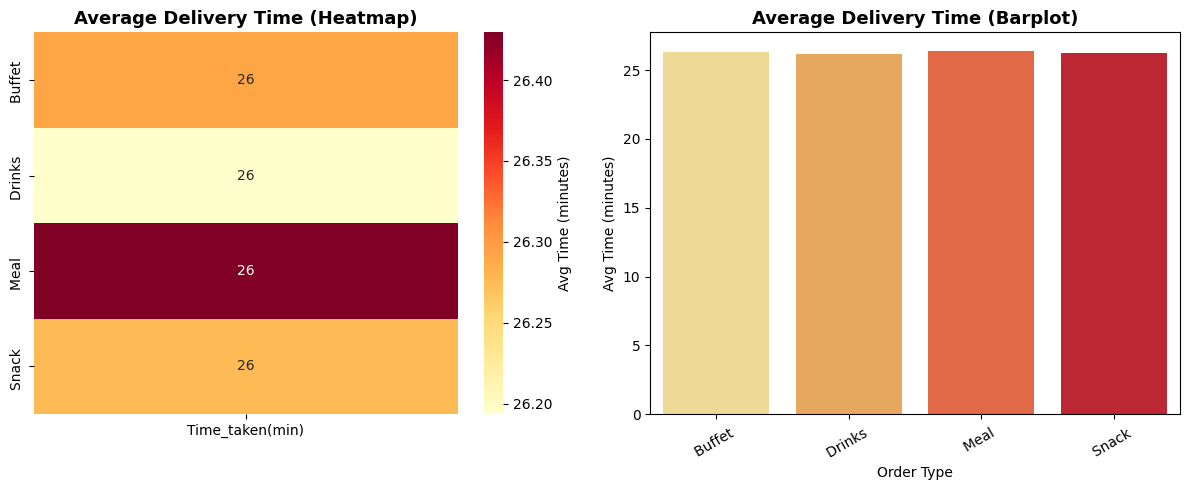

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = data.groupby("Type_of_order")["Time_taken(min)"].mean().reset_index()
pivot_table = pivot.pivot_table(values="Time_taken(min)", index="Type_of_order")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- Heatmap ---
ax1 = sns.heatmap(
    pivot_table,
    annot=True,
    cmap="YlOrRd",
    cbar=True,
    ax=axes[0]
)
axes[0].set_title("Average Delivery Time (Heatmap)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")


cbar = ax1.collections[0].colorbar
cbar.set_label("Avg Time (minutes)", fontsize=10)

# --- Barplot ---
sns.barplot(
    data=pivot,
    x="Type_of_order",
    y="Time_taken(min)",
    palette="YlOrRd",
    ax=axes[1]
)
axes[1].set_title("Average Delivery Time (Barplot)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Order Type")
axes[1].set_ylabel("Avg Time (minutes)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


# 8. Multiple Deliveries Impact
# Business Question: Do multiple deliveries per trip increase delivery time?

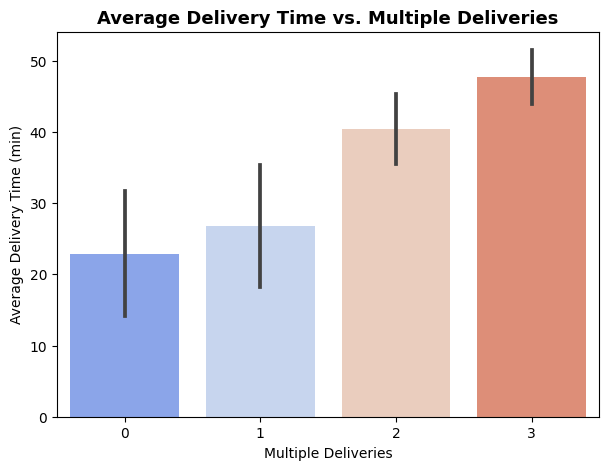

In [60]:
plt.figure(figsize=(7,5))
sns.barplot(x="multiple_deliveries", y="Time_taken(min)", data=data, palette="coolwarm", ci="sd")
plt.title("Average Delivery Time vs. Multiple Deliveries", fontsize=13, fontweight="bold")
plt.xlabel("Multiple Deliveries")
plt.ylabel("Average Delivery Time (min)")
plt.show()


# 9. Time Patterns (Day of Week / Hour)
# Business Question: Are there peak times/days when deliveries take longer?

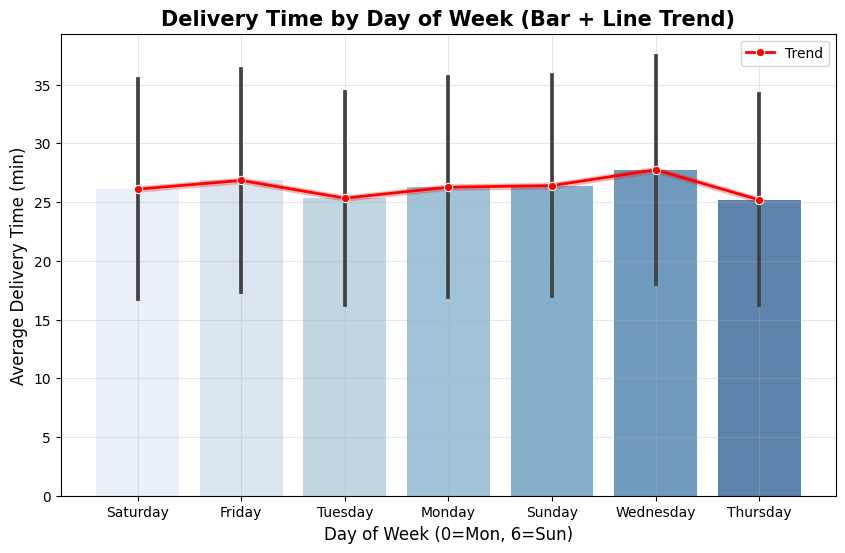

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(x="Day_of_week", y="Time_taken(min)", data=data, 
            palette="Blues", ci="sd", alpha=0.7)

sns.lineplot(x="Day_of_week", y="Time_taken(min)", data=data, 
             marker="o", color="red", linewidth=2, label="Trend")

plt.title("Delivery Time by Day of Week (Bar + Line Trend)", fontsize=15, fontweight="bold")
plt.xlabel("Day of Week (0=Mon, 6=Sun)", fontsize=12)
plt.ylabel("Average Delivery Time (min)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


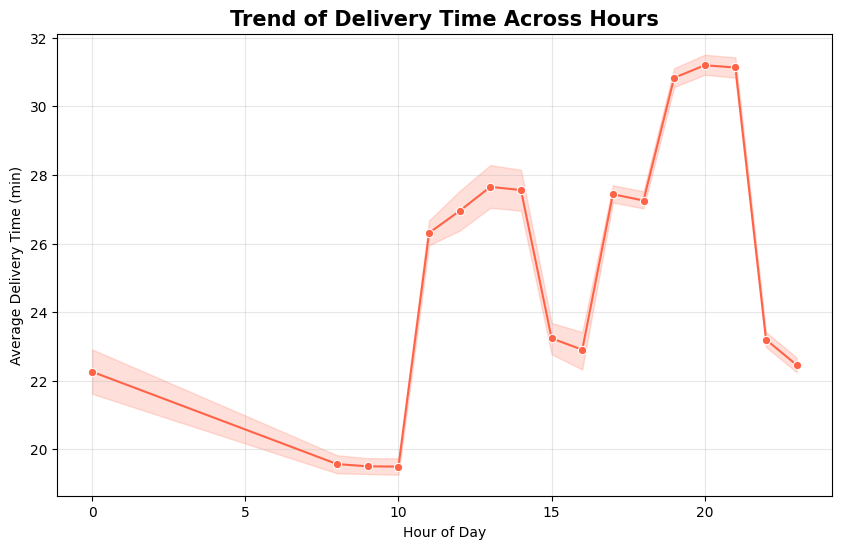

In [62]:
plt.figure(figsize=(10,6))
sns.lineplot(x="Hour", y="Time_taken(min)", data=data, marker="o", color="tomato")
plt.title("Trend of Delivery Time Across Hours", fontsize=15, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delivery Time (min)")
plt.grid(alpha=0.3)
plt.show()


# 10. Comparison between Festival days and normal days

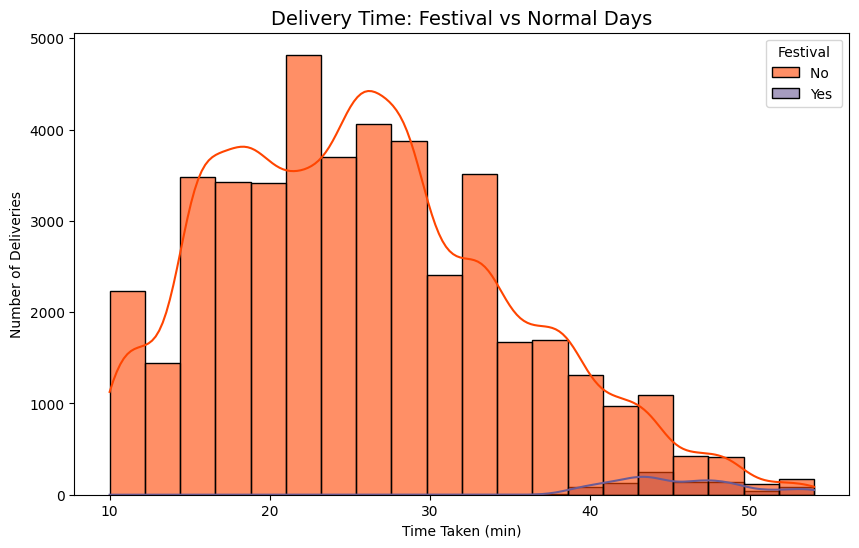

In [63]:
# Updated color palette: bright for festival, soft for normal
colors = ["#FF4500", "#6B5B95"]  # Yes = bright orange/red, No = purple

plt.figure(figsize=(10,6))
sns.histplot(
    data=data,
    x='Time_taken(min)',
    hue='Festival',
    bins=20,
    palette=colors,
    kde=True,        # add KDE curve
    stat='count',    # y-axis shows number of deliveries
    alpha=0.6        # transparent bars for visibility
)
plt.title('Delivery Time: Festival vs Normal Days', fontsize=14)
plt.xlabel('Time Taken (min)')
plt.ylabel('Number of Deliveries')
plt.show()

# 11. Correlation Heatmap
# Business Question: Which numerical features correlate with delivery time?

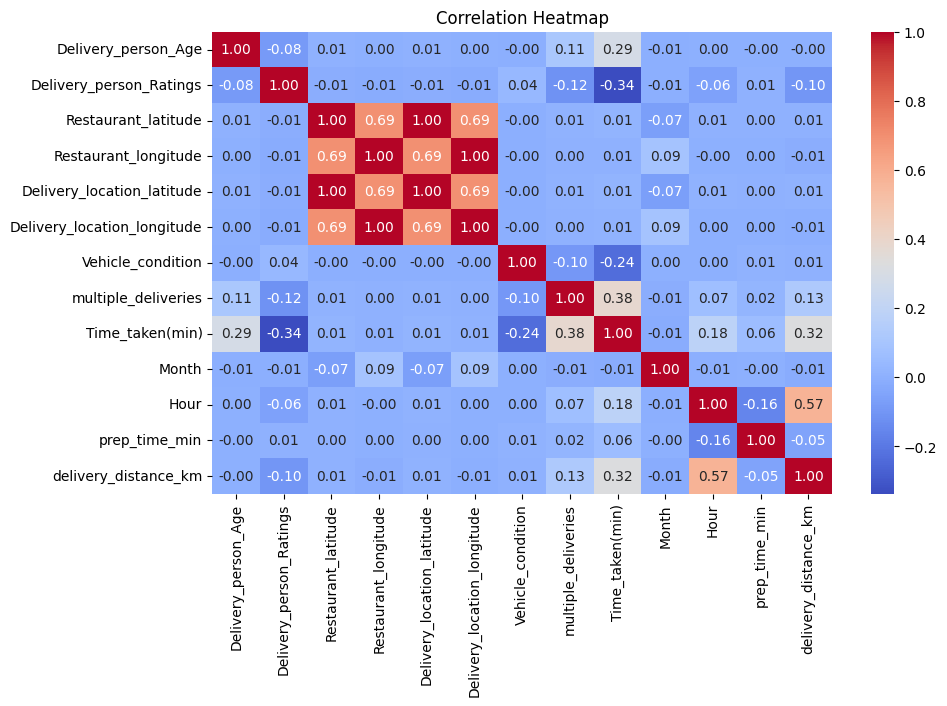

In [64]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Insights Summary
# 1. Delivery time is right-skewed → most deliveries are fast, few are very long.
# 2. City and Traffic Density strongly affect delivery time.
# 3. Bad weather increases delays.
# 4. Longer distances → longer delivery times (positive correlation).
# 5. Some order types take more time to prepare and deliver.
# 6. Multiple deliveries per trip increase delivery time.
# 7. Peak hours (lunch/dinner) show higher delivery times.
# 8. distance and prep time are main drivers.
# 9. Delivery Time in Festival Days takes longer time.


In [65]:
df = data.copy()

## Data Preprocessing and Models Testing

In [66]:
df.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,...,Festival,City,Time_taken(min),Time_Orderd_dt,Time_Order_picked_dt,Month,Hour,Day_of_week,prep_time_min,delivery_distance_km
0,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,...,No,Urban,24,2022-03-19 11:30:00,2022-03-19 11:45:00,3,11,Saturday,15.0,3.025149
1,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,...,No,Metropolitan,33,2022-03-25 19:45:00,2022-03-25 19:50:00,3,19,Friday,5.0,20.183530
2,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,...,No,Urban,26,2022-03-19 08:30:00,2022-03-19 08:45:00,3,8,Saturday,15.0,1.552758
3,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,...,No,Metropolitan,21,2022-04-05 18:00:00,2022-04-05 18:10:00,4,18,Tuesday,10.0,7.790401
4,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,...,No,Metropolitan,30,2022-03-26 13:30:00,2022-03-26 13:45:00,3,13,Saturday,15.0,6.210138


In [67]:
df.isna().sum()

Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
Time_Orderd_dt                 0
Time_Order_picked_dt           0
Month                          0
Hour                           0
Day_of_week                    0
prep_time_min                  0
delivery_distance_km           0
dtype: int64

- Extract some date features 

In [68]:
df["day"] = df.Order_Date.dt.day
df["quarter"] = df.Order_Date.dt.quarter
df["year"] = df.Order_Date.dt.year
df['day_of_week'] = df.Order_Date.dt.day_of_week.astype(int) # Changed the Day of week to number instead of string
df["is_month_start"] = df.Order_Date.dt.is_month_start.astype(int)
df["is_month_end"] = df.Order_Date.dt.is_month_end.astype(int)
df["is_quarter_start"] = df.Order_Date.dt.is_quarter_start.astype(int)
df["is_quarter_end"] = df.Order_Date.dt.is_quarter_end.astype(int)
df["is_year_start"] = df.Order_Date.dt.is_year_start.astype(int)
df["is_year_end"] = df.Order_Date.dt.is_year_end.astype(int)
df['is_weekend'] = np.where(df['day_of_week'].isin([5,6]),1,0)


df.head()

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,...,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend
0,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,...,1,2022,5,0,0,0,0,0,0,1
1,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,...,1,2022,4,0,0,0,0,0,0,0
2,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,...,1,2022,5,0,0,0,0,0,0,1
3,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,...,2,2022,1,0,0,0,0,0,0,0
4,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,...,1,2022,5,0,0,0,0,0,0,1


- Drop unimportant columns and columns with repeating information

In [69]:
df = df.drop(columns=["Hour", "Delivery_person_ID", "Order_Date", "Time_Orderd", "Time_Order_picked", "Time_Orderd_dt", "Time_Order_picked_dt"])
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,...,1,2022,5,0,0,0,0,0,0,1
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,...,1,2022,4,0,0,0,0,0,0,0
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,...,1,2022,5,0,0,0,0,0,0,1
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,...,2,2022,1,0,0,0,0,0,0,0
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,...,1,2022,5,0,0,0,0,0,0,1


- Label Encoding Categorical columns


In [70]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = df.select_dtypes(include='object').columns
label_encoder = LabelEncoder()

# Apply the encoder for all categorical columns
df[categorical_columns] = df[categorical_columns].apply(lambda col: label_encoder.fit_transform(col))

df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend
0,37,4.9,22.745049,75.892471,22.765049,75.912471,4,0,2,3,...,1,2022,5,0,0,0,0,0,0,1
1,34,4.5,12.913041,77.683237,13.043041,77.813237,3,1,2,3,...,1,2022,4,0,0,0,0,0,0,0
2,23,4.4,12.914264,77.678400,12.924264,77.688400,2,2,0,1,...,1,2022,5,0,0,0,0,0,0,1
3,38,4.7,11.003669,76.976494,11.053669,77.026494,4,3,0,0,...,2,2022,1,0,0,0,0,0,0,0
4,32,4.6,12.972793,80.249982,13.012793,80.289982,0,0,1,3,...,1,2022,5,0,0,0,0,0,0,1


### Data Splitting

In [71]:
from sklearn.model_selection import train_test_split

#Split features & label
X = df.drop('Time_taken(min)', axis=1)  # Features
y = df['Time_taken(min)']  # Target variable

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(36129, 29)
(36129,)
(9033, 29)
(9033,)


### Data Scaling

In [72]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data
scaler.fit(X_train)

# Perform standardization on the training data
X_train = scaler.transform(X_train)

# Perform standardization on the testing data
X_test = scaler.transform(X_test)

### Model Selection
- Employ cross-validation & hyper parameter tuning to determine the optimal regression model.

In [73]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Find the best model
models = [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(),
    xgb.XGBRegressor()
]

param_grid = [
    {},  
    {'max_depth': [3, 5, 7]},
    {'n_estimators': [100, 200, 300]},
    {'n_estimators': [20, 25, 30], 'max_depth': [5, 7, 9]},
]

for i, model in enumerate(models):
    grid_search = GridSearchCV(model, param_grid[i], cv=5, scoring='r2')
    grid_search.fit(X_train, y_train)

    print(f"{model.__class__.__name__}:")
    print("Best parameters:", grid_search.best_params_)
    print("Best R2 score:", grid_search.best_score_)
    print()

LinearRegression:
Best parameters: {}
Best R2 score: 0.4967521277985473

DecisionTreeRegressor:
Best parameters: {'max_depth': 7}
Best R2 score: 0.725539321148444

RandomForestRegressor:
Best parameters: {'n_estimators': 300}
Best R2 score: 0.81689934864981

XGBRegressor:
Best parameters: {'max_depth': 7, 'n_estimators': 20}
Best R2 score: 0.8232977009943403




### Trying out Polynomial Regression with Different Degrees

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

degrees_to_test = [1, 2, 3]
results = []

print("Starting Polynomial Regression analysis for different degrees...")
print("-" * 60)

for degree in degrees_to_test:
    
    print(f"Testing with Polynomial Degree: {degree}")

    pipeline = Pipeline(steps=[
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', LinearRegression())
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        'degree': degree,
        'r2': r2,
        'mae': mae,
        'rmse': rmse
    })
    
    print(f"  R-squared (R²): {r2:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")

# --- 2. Display Final Summary ---
print("\n" + "=" * 60)
print("              PERFORMANCE SUMMARY")
print("=" * 60)
print(f"{'Degree':<10} | {'R-squared':<15} | {'MAE':<15} | {'RMSE':<15} | {'Time (s)':<10}")
print("-" * 60)
for res in results:
    print(f"{res['degree']:<10} | {res['r2']:<15.4f} | {res['mae']:<15.4f} | {res['rmse']:<15.4f}")
print("=" * 60)

Starting Polynomial Regression analysis for different degrees...
------------------------------------------------------------
Testing with Polynomial Degree: 1
  R-squared (R²): 0.4912
  Root Mean Squared Error (RMSE): 6.7526
Testing with Polynomial Degree: 2
  R-squared (R²): 0.5885
  Root Mean Squared Error (RMSE): 6.0728
Testing with Polynomial Degree: 3
  R-squared (R²): -3432148164619769.0000
  Root Mean Squared Error (RMSE): 554588096.4976

              PERFORMANCE SUMMARY
Degree     | R-squared       | MAE             | RMSE            | Time (s)  
------------------------------------------------------------
1          | 0.4912          | 5.4041          | 6.7526         
2          | 0.5885          | 4.8511          | 6.0728         
3          | -3432148164619769.0000 | 8164449.7436    | 554588096.4976 


### Out of All models the best was XGBRegressor

In [75]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [76]:
# Create a XGB regressor model
best_model = xgb.XGBRegressor(n_estimators=20,max_depth=7)

# Fit the model on the training data
best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=20, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

### Evaluating The best model

In [77]:
# Make predictions on the test data
y_pred = best_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R-squared (R2) Score:", round(r2,2))

Mean Absolute Error (MAE): 3.13
Mean Squared Error (MSE): 15.68
Root Mean Squared Error (RMSE): 3.96
R-squared (R2) Score: 0.82


- Exporting the model to use in deployment

In [78]:
import joblib

try:
    joblib.dump(best_model, 'bestModel.pkl')
except:
    print("Error Model")

try:
    joblib.dump(scaler, 'sclaer.pkl')
except:
    print("Error Sclaer")

In [79]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken(min)', 'Month', 'Day_of_week', 'prep_time_min',
       'delivery_distance_km', 'day', 'quarter', 'year', 'day_of_week',
       'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end',
       'is_year_start', 'is_year_end', 'is_weekend'],
      dtype='object')

### Trying XBGRegressor with more different params and Regularizations

In [80]:
xgbr = xgb.XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],  # L1 regularization
    'reg_lambda': [1, 1.5, 2]     # L2 regularization
}

grid_search = GridSearchCV(
    estimator=xgbr,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("\nEvaluating the best model on the test set...")

# Get the best estimator found by the grid search
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test)

# Calculate final performance metrics
final_r2 = r2_score(y_test, y_pred)
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"  Final R-squared (R²): {final_r2:.4f}")
print(f"  Final Mean Absolute Error (MAE): {final_mae:.4f}")
print(f"  Final Root Mean Squared Error (RMSE): {final_rmse:.4f}")


Evaluating the best model on the test set...
  Final R-squared (R²): 0.8279
  Final Mean Absolute Error (MAE): 3.1040
  Final Root Mean Squared Error (RMSE): 3.9267
